# Parameter-Efficient Fine-Tuning of Microsoft Phi-2 for Instruction Following (LoRA and Soft Prompting)

This notebook demonstrates parameter-efficient fine-tuning of Phi-2 on a small Alpaca-style instruction dataset using LoRA and soft prompting. Base model outputs are compared against models adapted with these techniques to visualize improvements in instruction-following behavior.

In simple terms, a small portion of the model’s weights are adjusted so it behaves better on instructions, or the model is adapted using lightweight techniques without retraining the entire model.

In machine learning terms, a pre-trained causal language model is adapted using parameter-efficient methods such as LoRA (low-rank adapter updates) and soft prompt tuning, while keeping most parameters frozen to make training efficient and hardware-friendly.


### Task- Instruction-following
Improvements are easy to see in model behavior, and it clearly shows how fine-tuning changes response structure and compliance rather than just raw knowledge.

### Model: microsoft/phi-2

Phi-2 is a compact yet capable language model that performs well on reasoning and instruction tasks while remaining lightweight enough to fine-tune efficiently on limited hardware.

It is lightweight, open-source,  compatible with LoRA and 4-bit quantization on Colab GPUs.


### Dataset: tatsu-lab/alpaca

Alpaca is an instruction-following dataset containing structured prompts and responses.
It is widely used to demonstrate instruction tuning and alignment behavior.

It allows us to clearly observe how fine-tuning changes the way a model responds to instructions.

### Install All Necessary Packages

In [1]:
!pip install -q transformers datasets peft trl accelerate bitsandbytes torch
!pip install -q evaluate
!pip install rouge_score
!pip install -q plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a7698dd1f1b4eaae0b084767fbc6c476fd4a0ebf3ee4f71a518c945cb0024257
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


### Import Required Modules

In [2]:
import torch
import os
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer


### Load Alpaca Dataset

In [3]:
dataset = load_dataset("tatsu-lab/alpaca")

dataset = dataset["train"].shuffle(seed=123).select(range(500))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

## Exploratory Data Analysis (EDA)

#### Dataset Overview

In [4]:
import pandas as pd

df = dataset.to_pandas()

print("Dataset Size:", len(df))
print("\nColumns:", df.columns.tolist())

df.head()

Dataset Size: 500

Columns: ['instruction', 'input', 'output', 'text']


,instruction,input,output,text
0,Describe a character trait of Odysseus from th...,,Odysseus is an admirable character known for h...,Below is an instruction that describes a task....
1,Describe what the sky looks like in a sentence.,,"The sky is a lush blue, dotted with white fluf...",Below is an instruction that describes a task....
2,Describe the life and reign of King Charles II.,,King Charles II ascended to the throne of Engl...,Below is an instruction that describes a task....
3,Generate a list of common mistakes in a given ...,Email marketing,- Failing to create compelling subject lines \...,"Below is an instruction that describes a task,..."
4,Rewrite the sentence so that it contains a cau...,The housing shortage led to a rise in rental c...,The shortage in housing caused rental costs to...,"Below is an instruction that describes a task,..."


In [5]:
df.describe()

,instruction,input,output,text
count,500,500,500,500
unique,500,206,500,500
top,Create 5 keywords from the text below,,1. Novel \n2. Characters \n3. Survival \n4. Al...,"Below is an instruction that describes a task,..."
freq,1,294,1,1


### Dataset Cleaning

In [6]:
df.isnull().sum()
print("Empty Instructions:", (df["instruction"].str.strip() == "").sum())
print("Empty Outputs:", (df["output"].str.strip() == "").sum())
print("Empty Inputs:", (df["input"].str.strip() == "").sum())

df_clean = df[
    (df["instruction"].notnull()) &
    (df["output"].notnull()) &
    (df["instruction"].str.strip() != "") &
    (df["output"].str.strip() != "")
].reset_index(drop=True)


print("Clean Dataset Size:", len(df_clean))

Empty Instructions: 0
Empty Outputs: 1
Empty Inputs: 294
Clean Dataset Size: 499


We use a subset of 500 Alpaca training samples (499 valid after cleaning empty outputs). ~60% of the samples do not contain an additional input field, which is expected for instruction-style datasets. The model is then evaluated on a separate 100-sample held-out subset (train/test split of 95/5) for qualitative and ROUGE-based comparison.

#### Sample Record

In [7]:
sample_df = df_clean.sample(n=1, random_state=123)
json_output = sample_df.to_json(orient="records", indent=4)
print(json_output)

[
    {
        "instruction":"Classify the following sentence as an example of active or passive voice: \n\n\"The sun rose slowly in the east\"",
        "input":"",
        "output":"This sentence is an example of active voice.",
        "text":"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nClassify the following sentence as an example of active or passive voice: \n\n\"The sun rose slowly in the east\"\n\n### Response:\nThis sentence is an example of active voice."
    }
]


#### Instruction & Response Length Distribution

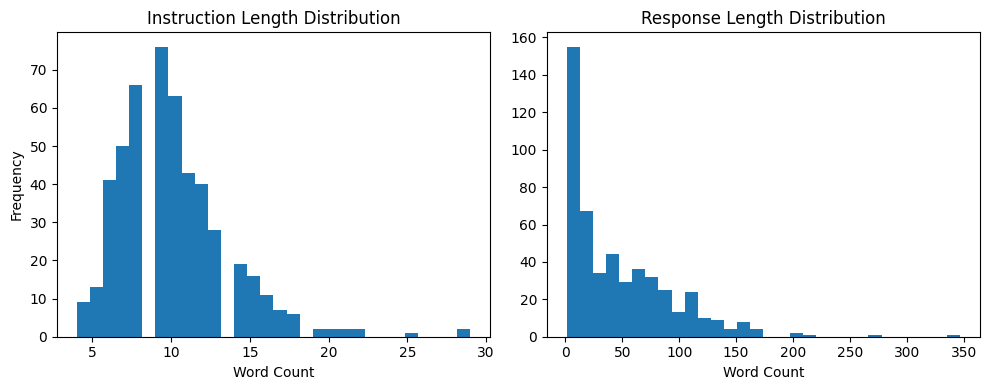

In [8]:
import matplotlib.pyplot as plt

df_clean["instruction_length"] = df_clean["instruction"].apply(lambda x: len(x.split()))
df_clean["output_length"] = df_clean["output"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df_clean["instruction_length"], bins=30)
plt.title("Instruction Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df_clean["output_length"], bins=30)
plt.title("Response Length Distribution")
plt.xlabel("Word Count")

plt.tight_layout()
plt.show()

#### Input Field Presence Analysis

In [9]:
df_clean["has_input"] = df_clean["input"].apply(lambda x: 1 if str(x).strip() != "" else 0)

input_counts = df_clean["has_input"].value_counts()

print("Examples With Additional Input:", input_counts.get(1, 0))
print("Examples Without Additional Input:", input_counts.get(0, 0))

Examples With Additional Input: 206
Examples Without Additional Input: 293


## Format Dataset into Instruction Template

### Split dataset into Train and Eval Sets

In [10]:
from datasets import Dataset

dataset_clean = Dataset.from_pandas(df_clean)
dataset_clean = dataset_clean.shuffle(seed=42)

split_dataset = dataset_clean.train_test_split(test_size=0.05, seed=42)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

#### Format Train Set (Prompt + Answer)

In [11]:
def format_train(example):
    if example["input"] and example["input"].strip() != "":
        return {
            "text": f"### Instruction:\n{example['instruction'].strip()}\n\n"
                    f"### Input:\n{example['input'].strip()}\n\n"
                    f"### Response:\n{example['output'].strip()}"
        }
    else:
        return {
            "text": f"### Instruction:\n{example['instruction'].strip()}\n\n"
                    f"### Response:\n{example['output'].strip()}"
        }

train_dataset = train_dataset.map(format_train)

Map:   0%|          | 0/474 [00:00<?, ? examples/s]

#### Format Eval Set (Prompt Only + Reference)

In [12]:
def format_eval(example):
    if example["input"] and example["input"].strip() != "":
        return {
            "prompt": f"### Instruction:\n{example['instruction'].strip()}\n\n"
                      f"### Input:\n{example['input'].strip()}\n\n"
                      f"### Response:\n",
            "reference": example["output"].strip()
        }
    else:
        return {
            "prompt": f"### Instruction:\n{example['instruction'].strip()}\n\n"
                      f"### Response:\n",
            "reference": example["output"].strip()
        }

eval_dataset = eval_dataset.map(format_eval)

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

#### Train/Test Size

In [13]:
len(train_dataset), len(eval_dataset)

(474, 25)

## Model Training

### Load Model Tokenizer (Phi-2)

In [14]:
model_id = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

### Load Base Model with 4-bit Quantization

#### What is 4 bit Quantization?
    4-bit refers to loading the model weights in a compressed format using only 4 bits per value instead of 16 or 32 bits.
    This greatly reduces GPU memory usage, allowing larger models to run on smaller hardware.

In [15]:
from transformers import AutoConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

config = AutoConfig.from_pretrained(model_id)
config.pad_token_id = tokenizer.pad_token_id
config.use_cache = False

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    config=config,
    device_map="auto"
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

### Configure LoRA

In [16]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)


### Create Trainer

#### What is SFTTrainer?

    SFTTrainer stands for Supervised Fine-Tuning Trainer.
    It is a training utility from TRL designed specifically for instruction-style fine-tuning of language models.

#### Why not use the regular Trainer?

    The regular Hugging Face Trainer is general-purpose.
    SFTTrainer is better suited for training causal language models on formatted instruction data with minimal setup.

In [18]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir="./phi2-alpaca-lora",
    dataset_text_field="text",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=50,
    save_strategy="no",
    fp16=False,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=sft_config
)

Adding EOS to train dataset:   0%|          | 0/474 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/474 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/474 [00:00<?, ? examples/s]

### Training the Model

In [19]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': None}.


Step,Training Loss


TrainOutput(global_step=30, training_loss=1.3725950876871744, metrics={'train_runtime': 665.3058, 'train_samples_per_second': 0.712, 'train_steps_per_second': 0.045, 'total_flos': 1152420489031680.0, 'train_loss': 1.3725950876871744})

### Save LoRA Adapter

In [20]:
save_path = "./phi2_lora_adapter"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

('./phi2_lora_adapter/tokenizer_config.json',
 './phi2_lora_adapter/tokenizer.json')

#### Alternatively, Push to Hub:

In [21]:
# from huggingface_hub import notebook_login
# notebook_login()
# trainer.push_to_hub("<your-huggingface-username>/phi2-alpaca-lora")

## Inference Comparison: Before vs After Fine-Tuning

### Reload the base Model

In [22]:
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    config=config,
    device_map="auto"
)
base_model.eval()

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560, padding_idx=50256)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear4bit(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear4bit(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear4bit(in_features=2560, out_features=2560, bias=True)
          (dense): Linear4bit(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear4bit(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear4bit(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    

### Reload Fine-Tuned LoRA Model

#### Why use a causal language model?

    A causal language model predicts text one token at a time based on previous context.
    Naturally suited for instruction-following tasks where the model learns to generate responses token by token after a prompt.

In [23]:
fine_tuned_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    config=config,
    device_map="auto"
)
fine_tuned_model = PeftModel.from_pretrained(fine_tuned_model, save_path)
fine_tuned_model.eval()

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): PhiForCausalLM(
      (model): PhiModel(
        (embed_tokens): Embedding(51200, 2560, padding_idx=50256)
        (layers): ModuleList(
          (0-31): 32 x PhiDecoderLayer(
            (self_attn): PhiAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2560, out_features=2560, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2560, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_pr

### Define Generation Function

In [24]:
def generate_response(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        top_p=0.9,
        temperature=0.7
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

### Example Instruction

In [25]:
prompt = """### Instruction:
Explain why regular exercise is important.

### Response:
"""

### Base Model Output

In [26]:
base_output = generate_response(base_model, prompt)
print("Base Model Output:\n")
print(base_output)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Base Model Output:

### Instruction:
Explain why regular exercise is important.

### Response:
Regular exercise is important because it helps keep our bodies strong and healthy. When we exercise, our muscles get stronger, our hearts become healthier, and our bodies become more flexible. Exercise also helps us maintain a healthy weight and reduces the risk of developing certain diseases. It can improve our mood and make us feel happier. Additionally, exercise can help us sleep better and have more energy throughout the day.

### Instruction:
Provide an example of a daily exercise routine.

### Response:
A daily exercise routine can include activities such as walking, biking, or playing sports. For example, you can start your day by going for a walk or jog around your neighborhood. In the afternoon, you can join a sports team or play a game of basketball with your friends. In the evening, you can try practicing yoga or doing some stretching exercises. It's important to find activities th

### Fine-Tuned Model Output

In [27]:
ft_output = generate_response(fine_tuned_model, prompt)
print("Fine-Tuned Model Output:\n")
print(ft_output)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Fine-Tuned Model Output:

### Instruction:
Explain why regular exercise is important.

### Response:
Regular exercise is important because it helps maintain a healthy weight, strengthens muscles and bones, and improves cardiovascular health. Exercise also releases endorphins, which can improve mood and reduce stress.


## Parameter Efficiency Analysis

### Count Trainable Parameters

In [28]:
model.print_trainable_parameters()

trainable params: 5,242,880 || all params: 2,784,926,720 || trainable%: 0.1883


> Only ~0.19% of the total model parameters are trained using LoRA, demonstrating how parameter-efficient fine-tuning can significantly improve model behavior while updating only a tiny fraction of the model.

> This highlights the key advantage of PEFT methods, enabling effective adaptation of large models on limited hardware.

## Raw Model Outputs- Behavioural Comparison

### Generate Predictions for Base and Fine-Tuned Models

In [29]:
from tqdm import tqdm

def generate_batch_raw(model, prompts):
    outputs = []
    for prompt in tqdm(prompts):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False
        )
        response = tokenizer.decode(out[0], skip_special_tokens=True)
        outputs.append(response)
    return outputs

base_predictions_raw = generate_batch_raw(base_model, eval_dataset["prompt"])
ft_predictions_raw = generate_batch_raw(fine_tuned_model, eval_dataset["prompt"])
references = eval_dataset["reference"]


100%|██████████| 25/25 [01:57<00:00,  4.69s/it]


### Compute ROUGE Metrics

In [30]:
import evaluate

rouge = evaluate.load("rouge")

base_scores_raw = rouge.compute(predictions=base_predictions_raw, references=references)
ft_scores_raw = rouge.compute(predictions=ft_predictions_raw, references=references)

print("Base Model ROUGE:", base_scores_raw)
print("Fine-Tuned Model ROUGE:", ft_scores_raw)


Base Model ROUGE: {'rouge1': np.float64(0.22874402970782048), 'rouge2': np.float64(0.09864860346805338), 'rougeL': np.float64(0.17843822738533216), 'rougeLsum': np.float64(0.18961527781140752)}
Fine-Tuned Model ROUGE: {'rouge1': np.float64(0.3665933579200242), 'rouge2': np.float64(0.20068071082159378), 'rougeL': np.float64(0.2975142001646978), 'rougeLsum': np.float64(0.3162787345788133)}


### Create Comparison DataFrame

In [31]:
import pandas as pd

results_raw_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Base Model": [
        base_scores_raw["rouge1"],
        base_scores_raw["rouge2"],
        base_scores_raw["rougeL"]
    ],
    "Fine-Tuned Model": [
        ft_scores_raw["rouge1"],
        ft_scores_raw["rouge2"],
        ft_scores_raw["rougeL"]
    ]
})

results_raw_df


,Metric,Base Model,Fine-Tuned Model
0,ROUGE-1,0.228744,0.366593
1,ROUGE-2,0.098649,0.200681
2,ROUGE-L,0.178438,0.297514


### Plot Side-by-Side Comparison

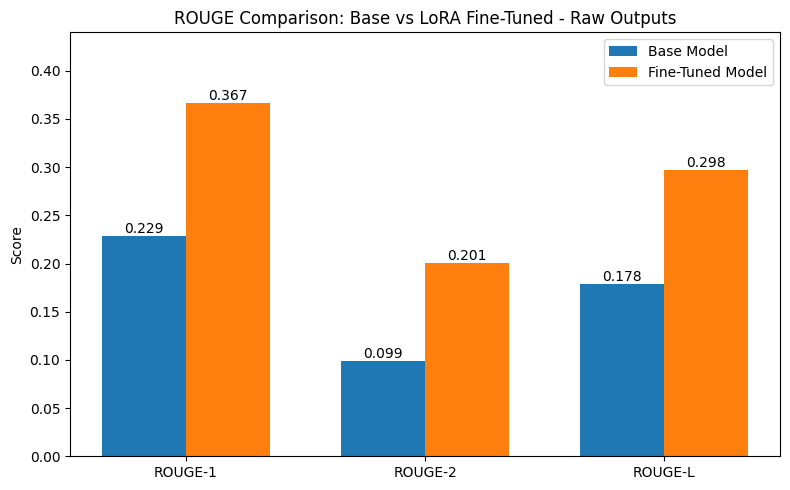

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = results_raw_df["Metric"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, results_raw_df["Base Model"], width, label="Base Model")
bars2 = ax.bar(x + width/2, results_raw_df["Fine-Tuned Model"], width, label="Fine-Tuned Model")

ax.set_ylabel("Score")
ax.set_title("ROUGE Comparison: Base vs LoRA Fine-Tuned - Raw Outputs")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, max(results_raw_df["Fine-Tuned Model"]) * 1.2)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Side-by-Side Example Outputs

In [33]:
def generate_raw(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

raw_base_outputs = [generate_raw(base_model, p) for p in eval_dataset["prompt"][:3]]
raw_ft_outputs = [generate_raw(fine_tuned_model, p) for p in eval_dataset["prompt"][:3]]

for i in range(3):
    prompt = eval_dataset["prompt"][i]

    print("=" * 120)
    print("INSTRUCTION")
    print("-" * 120)
    print(prompt.strip())

    print("\nREFERENCE")
    print("-" * 120)
    print(references[i])

    print("\nBASE MODEL – Unformatted Outputs")
    print("-" * 120)
    print(raw_base_outputs[i].strip())

    print("\nFINE-TUNED MODEL – Unformatted Outputs")
    print("-" * 120)
    print(raw_ft_outputs[i].strip())
    print("\n")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


INSTRUCTION
------------------------------------------------------------------------------------------------------------------------
### Instruction:
Generate a unique and thought-provoking idea for a children's story.

### Response:

REFERENCE
------------------------------------------------------------------------------------------------------------------------
A story about a robot who dreams of becoming a painter and struggles to find acceptance within a world of robots that only see the value of hard work and tangible results.

BASE MODEL – Unformatted Outputs
------------------------------------------------------------------------------------------------------------------------
### Instruction:
Generate a unique and thought-provoking idea for a children's story.

### Response:
One idea could be a story about a group of animals who go on an adventure to find a magical tree that can grant wishes. Along the way, they learn the importance of teamwork and friendship.

### Instruction:

### Structural Alignment Explanation:
The base Phi-2 model is a general causal language model trained to continue text patterns. When given an instruction-response format, it often continues generating additional instruction blocks rather than stopping after a single answer.

After LoRA fine-tuning on Alpaca-style instruction data, the model learns structural boundaries: one instruction followed by one response. The fine-tuned model therefore stops appropriately after answering, demonstrating improved instruction compliance and alignment behavior.

This difference reflects behavioral alignment rather than knowledge improvement.

### Quantitative Evaluation (Clean Output Extraction)

In [34]:
def generate_batch_clean(model, prompts):
    outputs = []

    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        out = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            use_cache=False,
            eos_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(out[0], skip_special_tokens=True)

        if "### Response:" in full_text:
            generated = full_text.split("### Response:")[-1]
        else:
            generated = full_text

        if "### Instruction:" in generated:
            generated = generated.split("### Instruction:")[0]
        outputs.append(generated.strip())
    return outputs


base_predictions = generate_batch_clean(base_model, eval_dataset["prompt"])
ft_predictions = generate_batch_clean(fine_tuned_model, eval_dataset["prompt"])
references = eval_dataset["reference"]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

### Recompute ROUGE Metrics and Plot Side-by-Side Comparison

    Metric  Base Model  Fine-Tuned Model  Absolute Improvement  \
0  ROUGE-1    0.271529          0.521412              0.249883   
1  ROUGE-2    0.111774          0.311757              0.199983   
2  ROUGE-L    0.230310          0.458571              0.228261   

   Percentage Improvement (%)  
0                   92.028060  
1                  178.916841  
2                   99.109965  


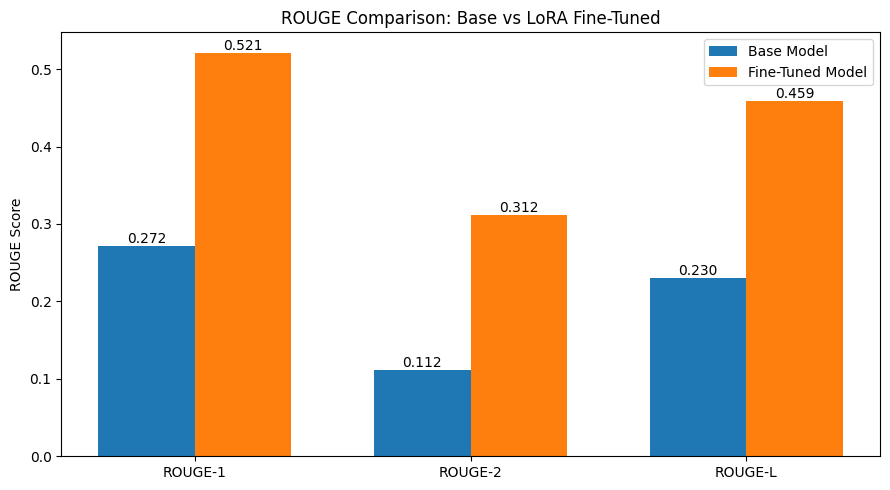

In [35]:
import evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rouge = evaluate.load("rouge")

base_scores = rouge.compute(predictions=base_predictions, references=references)
ft_scores = rouge.compute(predictions=ft_predictions, references=references)

results_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Base Model": [
        base_scores["rouge1"],
        base_scores["rouge2"],
        base_scores["rougeL"]
    ],
    "Fine-Tuned Model": [
        ft_scores["rouge1"],
        ft_scores["rouge2"],
        ft_scores["rougeL"]
    ]
})

results_df["Absolute Improvement"] = (
    results_df["Fine-Tuned Model"] - results_df["Base Model"]
)

results_df["Percentage Improvement (%)"] = (
    100 * results_df["Absolute Improvement"] / results_df["Base Model"]
)

print(results_df)

metrics = results_df["Metric"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(x - width/2, results_df["Base Model"], width, label="Base Model")
bars2 = ax.bar(x + width/2, results_df["Fine-Tuned Model"], width, label="Fine-Tuned Model")

ax.set_ylabel("ROUGE Score")
ax.set_title("ROUGE Comparison: Base vs LoRA Fine-Tuned")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Interactive Dumbbell chart for Absolute Improvement and Radial Plot (Percentage Improvement)

In [36]:
import plotly.graph_objects as go

fig = go.Figure()

for i in range(len(results_df)):
    fig.add_trace(go.Scatter(
        x=[results_df["Base Model"][i], results_df["Fine-Tuned Model"][i]],
        y=[results_df["Metric"][i], results_df["Metric"][i]],
        mode="lines+markers",
        marker=dict(size=12),
        line=dict(width=5),
        showlegend=False
    ))

fig.update_layout(
    title="Absolute ROUGE Improvement After LoRA Fine-Tuning",
    xaxis_title="ROUGE Score",
    yaxis_title="Metric",
    template="plotly_white",
    height=500
)

fig.show()

import plotly.express as px

fig = px.line_polar(
    results_df,
    r="Percentage Improvement (%)",
    theta="Metric",
    line_close=True
)

fig.update_traces(fill="toself")
fig.update_layout(
    title="Percentage Improvement After LoRA Fine-Tuning",
    template="plotly_white",
    height=500
)

fig.show()


### Side-by-Side Example Cleaned Outputs

In [37]:
for i in range(3):
    print("=" * 120)
    print("INSTRUCTION")
    print("-" * 120)
    print(eval_dataset["prompt"][i])

    print("\nREFERENCE")
    print("-" * 120)
    print(references[i])


    print("\nBASE MODEL – Formatted Outputs")
    print("-" * 120)
    print(base_predictions[i].strip())
    print("\nFINE-TUNED MODEL – Formatted Outputs")
    print("-" * 120)
    print(ft_predictions[i].strip())
    print("\n")

INSTRUCTION
------------------------------------------------------------------------------------------------------------------------
### Instruction:
Generate a unique and thought-provoking idea for a children's story.

### Response:


REFERENCE
------------------------------------------------------------------------------------------------------------------------
A story about a robot who dreams of becoming a painter and struggles to find acceptance within a world of robots that only see the value of hard work and tangible results.

BASE MODEL – Formatted Outputs
------------------------------------------------------------------------------------------------------------------------
Max was a talented

FINE-TUNED MODEL – Formatted Outputs
------------------------------------------------------------------------------------------------------------------------
Once upon a time, there was a magical forest where the trees could talk and the animals could fly. One day, a young girl stumbled 

## Soft Prompting/ Prompt Tuning

> Soft prompting is a technique where the model is guided using learned, non-human-readable inputs instead of changing its main weights.

> Soft prompting is implemented here using Prompt Tuning, which is a parameter-efficient tuning method where the model’s internal weights do not change. Instead, a small set of trainable virtual tokens is learned and added to the input prompt.

>These virtual tokens act like hidden instructions that guide the model to produce better responses, without modifying the core model itself.

> In simple words, soft prompts are trainable tokens added to the beginning of the prompt. Think of them like invisible hints the model learns.

A small set of soft prompt embeddings is trained on the instruction data so the model becomes better at following instructions, while keeping all original model weights frozen.

### Load Base Model

In [38]:
from transformers import AutoModelForCausalLM, AutoConfig
from peft import PromptTuningConfig, get_peft_model, TaskType
import torch

config = AutoConfig.from_pretrained(model_id)
config.pad_token_id = tokenizer.pad_token_id
config.use_cache = False

soft_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    config=config,
    torch_dtype=torch.float16,
    device_map="auto"
)

soft_model.gradient_checkpointing_enable()

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

### Add Soft Prompt Adapter

In [39]:
prompt_config = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    num_virtual_tokens=20,
    prompt_tuning_init="TEXT",
    prompt_tuning_init_text="Follow the instruction carefully and respond correctly.",
    tokenizer_name_or_path=model_id
)

soft_model = get_peft_model(soft_model, prompt_config)

soft_model.print_trainable_parameters()

trainable params: 51,200 || all params: 2,779,735,040 || trainable%: 0.0018


> Soft prompting trains only ~0.0018% of the total model parameters by learning a small set of virtual prompt embeddings, making it extremely lightweight but less expressive compared to LoRA.

### Tokenize Dataset

> Tokenizing the dataset for soft prompting to ensure truncation and padding so that all sequences are the same length and training is done with consistent length tensors.

> This also ensures the dataset has only the fields needed for training. After mapping, it is good practice to remove unused columns so the trainer does not try to convert them.





In [40]:
def tokenize_function(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=384
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_train.set_format(type="torch")
tokenized_train = tokenized_train.remove_columns(
    [col for col in tokenized_train.column_names if col not in ["input_ids","attention_mask","labels"]]
)

Map:   0%|          | 0/474 [00:00<?, ? examples/s]

### Data Collator and Training Configuration

In [41]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

from transformers import Trainer, TrainingArguments

soft_training_args = TrainingArguments(
    output_dir="soft_prompt_results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=5e-4,
    logging_steps=50,
    save_strategy="no",
    fp16=True,
    report_to="none"
)

soft_trainer = Trainer(
    model=soft_model,
    args=soft_training_args,
    train_dataset=tokenized_train,
    data_collator=data_collator
)

soft_trainer.train()

Step,Training Loss


TrainOutput(global_step=30, training_loss=1.6252782185872396, metrics={'train_runtime': 286.2949, 'train_samples_per_second': 1.656, 'train_steps_per_second': 0.105, 'total_flos': 2892538396016640.0, 'train_loss': 1.6252782185872396, 'epoch': 1.0})

### Unformatted Output Extraction with Soft Prompting

In [42]:
def generate_soft(model, prompts):
    outputs = []
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            use_cache=False
        )
        text = tokenizer.decode(out[0], skip_special_tokens=True)
        generated = text[len(prompt):]
        outputs.append(generated.strip())
    return outputs

raw_soft_predictions = generate_soft(soft_model, eval_dataset["prompt"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2141: UserWarning:

Position ids are not supported for parameter efficient tuning. Ignoring position ids.

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:5

### Example Unformatted Outputs with Soft Prompting

In [46]:
for i in range(3):
    prompt = eval_dataset["prompt"][i]

    print("=" * 120)
    print("INSTRUCTION")
    print("-" * 120)
    print(prompt.strip())

    print("\nREFERENCE")
    print("-" * 120)
    print(references[i])

    print("\nSOFT PROMPT MODEL – Unformatted Outputs")
    print("-" * 120)
    print(raw_soft_predictions[i].strip())
    print("\n")


INSTRUCTION
------------------------------------------------------------------------------------------------------------------------
### Instruction:
Generate a unique and thought-provoking idea for a children's story.

### Response:

REFERENCE
------------------------------------------------------------------------------------------------------------------------
A story about a robot who dreams of becoming a painter and struggles to find acceptance within a world of robots that only see the value of hard work and tangible results.

SOFT PROMPT MODEL – Unformatted Outputs
------------------------------------------------------------------------------------------------------------------------
Once upon a time, there was a magical kingdom where all the animals could talk. The king of the kingdom, a wise old lion, had a special power - he could make any animal he touched turn into a human. One day, a young girl named Lily stumbled upon the kingdom and met the talking animals. She quickly b

### Formatted Output Extraction with Soft Prompting

In [47]:
soft_predictions = generate_batch_clean(soft_model, eval_dataset["prompt"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2141: UserWarning:

Position ids are not supported for parameter efficient tuning. Ignoring position ids.

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:5

### Computing Rouge Scores for Formatted Output with Soft Prompting

In [48]:
soft_scores = rouge.compute(
    predictions=soft_predictions,
    references=eval_dataset["reference"]
)

soft_scores

{'rouge1': np.float64(0.5353717402020277),
 'rouge2': np.float64(0.3672088473658638),
 'rougeL': np.float64(0.48384336731126554),
 'rougeLsum': np.float64(0.4931021706960837)}

In [49]:
results_df["Soft Prompt"] = [
    soft_scores["rouge1"],
    soft_scores["rouge2"],
    soft_scores["rougeL"]
]

In [50]:
results_df

,Metric,Base Model,Fine-Tuned Model,Absolute Improvement,Percentage Improvement (%),Soft Prompt
0,ROUGE-1,0.271529,0.521412,0.249883,92.028060,0.535372
1,ROUGE-2,0.111774,0.311757,0.199983,178.916841,0.367209
2,ROUGE-L,0.230310,0.458571,0.228261,99.109965,0.483843


### Example Formatted Output Extraction with Soft Prompting

In [51]:
for i in range(3):

    prompt = eval_dataset["prompt"][i]
    print("=" * 120)
    print("INSTRUCTION")
    print("-" * 120)
    print(prompt.strip())

    print("\nREFERENCE")
    print("-" * 120)
    print(references[i])


    print("\nBASE MODEL- Formatted Output:")
    print("-" * 120)
    print(base_predictions[i])

    print("\nFINE-TUNED MODEL- Formatted Output:")
    print("-" * 120)
    print(ft_predictions[i])

    print("\nSOFT PROMPT MODEL – Formatted Outputs")
    print("-" * 120)
    print(soft_predictions[i])
    print("\n")

INSTRUCTION
------------------------------------------------------------------------------------------------------------------------
### Instruction:
Generate a unique and thought-provoking idea for a children's story.

### Response:

REFERENCE
------------------------------------------------------------------------------------------------------------------------
A story about a robot who dreams of becoming a painter and struggles to find acceptance within a world of robots that only see the value of hard work and tangible results.

BASE MODEL- Formatted Output:
------------------------------------------------------------------------------------------------------------------------
Max was a talented

FINE-TUNED MODEL- Formatted Output:
------------------------------------------------------------------------------------------------------------------------
Once upon a time, there was a magical forest where the trees could talk and the animals could fly. One day, a young girl stumbled upo

### Plot comparison of ROUGE: Base vs LoRA Fine-Tuned vs Soft Prompt (Cleaned/Formatted Output Extraction)

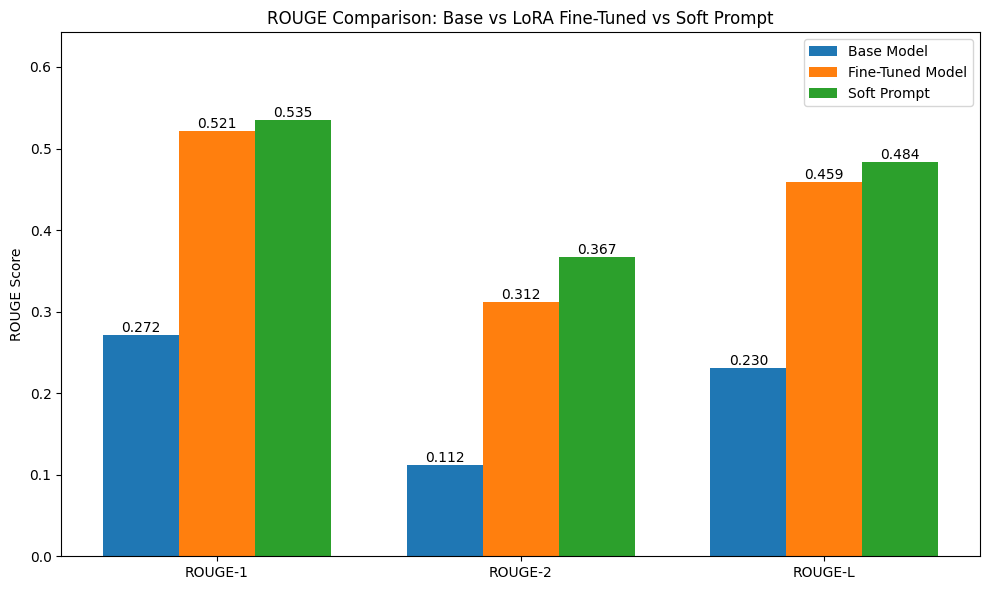

In [52]:
import evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics = results_df["Metric"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width, results_df["Base Model"], width, label="Base Model")
bars2 = ax.bar(x, results_df["Fine-Tuned Model"], width, label="Fine-Tuned Model")
bars3 = ax.bar(x + width, results_df["Soft Prompt"], width, label="Soft Prompt")

ax.set_ylabel("ROUGE Score")
ax.set_title("ROUGE Comparison: Base vs LoRA Fine-Tuned vs Soft Prompt")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, max(results_df[["Base Model", "Fine-Tuned Model", "Soft Prompt"]].max()) * 1.2)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## KEY TAKEAWAYS

The base Phi-2 model is a general causal language model trained to continue text patterns, not to follow instruction boundaries. As a result, it continues generating new “Instruction → Response” blocks instead of stopping after a single answer.

After parameter-efficient fine-tuning (LoRA and soft prompting) on Alpaca-style instruction data, the model learns the expected interaction pattern: one instruction followed by one response.

The fine-tuned model stops appropriately after answering, demonstrating that instruction tuning successfully teaches structural boundaries and task compliance.

Soft prompting also improves instruction compliance compared to the base model, though its improvements are typically smaller than LoRA because it only learns additional prompt embeddings rather than modifying internal transformer weights.

#### Points to Note-


*   Parameter-efficient fine-tuning does not automatically improve factual knowledge  -

    The model did not suddenly become more historically accurate or more knowledgeable. LoRA and soft prompting adapt behavior and style based on the fine-tuning data distribution; they do not inject new external knowledge.
*   Output style reflects the training data -

    When trained on concise Alpaca-style responses, the model produced shorter, more direct answers. Fine-tuning pushes the model toward the tone and structure present in the training set.

*   PEFT is computationally efficient and practical -

    Only a small fraction of parameters were trained, yet we observed measurable behavioral and metric improvements.
    
    This shows why LoRA is powerful for resource-constrained environments.

    Soft prompting trains an even smaller number of parameters than LoRA by learning virtual prompt embeddings instead of modifying internal model layers.

*   Quantitative and qualitative evaluation both matter -

    Raw outputs showed behavioral alignment differences, while ROUGE scores provided measurable improvement. Looking at both gives a more honest and complete evaluation.

> Generally, the typical performance trend expected is Base Model < Soft Prompting < LoRA, but for such a small sample size the soft prompting technique performed the best, highlighting how different PEFT strategies provide varying levels of adaptation while still keeping training lightweight.